In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processor import clean_narrative

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
RAW_PATH = '../data/raw/complaints.csv'
df_raw = pd.read_csv(RAW_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

C:\Users\A\AppData\Local\Temp\ipykernel_7132\1226548578.py:2: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(RAW_PATH)


Shape: (9609797, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


In [3]:

# --- EDA: Distribution of Products ---
print("\n--- EDA: Product Distribution ---")
print(df_raw['Product'].value_counts())


--- EDA: Product Distribution ---
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                      

In [4]:
# EDA
print('=== Column names ===')
print(df_raw.columns.tolist())
print(f'\n=== Total records: {len(df_raw):,} ===')
print(f'Missing values (%):\n{(df_raw.isnull().mean() * 100).round(1)}')

=== Column names ===
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

=== Total records: 9,609,797 ===
Missing values (%):
Date received                    0.0
Product                          0.0
Sub-product                      2.4
Issue                            0.0
Sub-issue                        8.7
Consumer complaint narrative    69.0
Company public response         49.6
Company                          0.0
State                            0.6
ZIP code                         0.3
Tags                            93.5
Consumer consent provided?      17.2
Submitted via                    0.0
Date sent to company             0.0
Company response to consumer     0.0
Timely response?                 0.0
Consume

With narrative:    2,980,756 (31.0%)
Without narrative: 6,629,041 (69.0%)


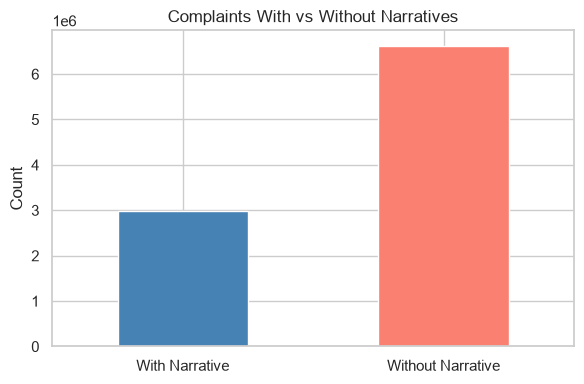

In [5]:
# Narratives: present vs absent
narrative_col = 'Consumer complaint narrative'
has_narrative = df_raw[narrative_col].notna() & (df_raw[narrative_col].astype(str).str.strip() != '')
print(f'With narrative:    {has_narrative.sum():>8,} ({has_narrative.mean():.1%})')
print(f'Without narrative: {(~has_narrative).sum():>8,} ({(~has_narrative).mean():.1%})')

fig, ax = plt.subplots(figsize=(6, 4))
pd.Series({'With Narrative': has_narrative.sum(), 'Without Narrative': (~has_narrative).sum()}).plot(
    kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white'
)
ax.set_title('Complaints With vs Without Narratives')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/narrative_availability.png', dpi=120)
plt.show()

In [7]:
word_counts = (
    df_raw.loc[has_narrative, narrative_col]
          .str.count(r"\S+")
)

print(word_counts.describe())


count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: Consumer complaint narrative, dtype: float64


In [8]:
# filter
from src.data_processor import TARGET_PRODUCTS
df_filtered = df_raw.copy()

df_filtered["Product"] = (
    df_filtered["Product"]
    .str.lower()
    .str.strip()
    .map(TARGET_PRODUCTS)
)

df_filtered = df_filtered[
    df_filtered["Product"].notna()
]

df_filtered = df_filtered[
    df_filtered["Consumer complaint narrative"].notna()
    & (df_filtered["Consumer complaint narrative"].str.strip() != "")
]

print(f"Filtered shape: {df_filtered.shape}")

print("\nProduct counts:")
print(df_filtered["Product"].value_counts())

Filtered shape: (445576, 18)

Product counts:
Product
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       17238
Name: count, dtype: int64


In [9]:
df_filtered.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
12237,2025-06-13,Credit Card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121
12532,2025-06-13,Savings Account,Checking account,Managing an account,Deposits and withdrawals,I made the mistake of using my wellsfargo debi...,Company has responded to the consumer and the ...,WELLS FARGO & COMPANY,ID,83815,NaN,Consent provided,Web,2025-06-13,Closed with explanation,Yes,NaN,14061897
13280,2025-06-12,Credit Card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085
13506,2025-06-12,Credit Card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217
13955,2025-06-09,Credit Card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411


In [10]:
# Clean narratives
df_filtered['narrative'] = df_filtered['Consumer complaint narrative']
df_filtered['clean_narrative'] = df_filtered['narrative'].apply(clean_narrative)
df_filtered['word_count'] = df_filtered['clean_narrative'].str.split().str.len()
df_clean = df_filtered[df_filtered['clean_narrative'].str.len() > 20].copy().reset_index(drop=True)

print(f'After cleaning: {df_clean.shape}')
print('\nWord count stats after cleaning:')
print(df_clean['word_count'].describe())

After cleaning: (445456, 21)

Word count stats after cleaning:
count    445456.000000
mean        197.869936
std         218.441168
min           1.000000
25%          79.000000
50%         131.000000
75%         245.000000
max        6263.000000
Name: word_count, dtype: float64


In [11]:
OUTPUT_PATH = '../data/processed/filtered_complaints.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(df_clean):,} records to {OUTPUT_PATH}')

Saved 445,456 records to ../data/processed/filtered_complaints.csv
